# Clustering audio à partir des fichiers chroma

On commence ici par étudier le datatset Cross-composer composé d'oeuvres de 11 compositeurs, l'objectif étant d'élargir avec le dataset Cross-era qui pourrait permettre de faire du clustering sur des périodes musicales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio

In [2]:
def verbose(message, verbose_level, verbose_threshold=0):
    if verbose_level > verbose_threshold:
        print(message)

In [3]:
filename = "cross-composer\chroma-nnls_01_bach.csv"
li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']

<>:1: SyntaxWarning:

invalid escape sequence '\c'

<>:1: SyntaxWarning:

invalid escape sequence '\c'

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\2910331894.py:1: SyntaxWarning:

invalid escape sequence '\c'



In [4]:
def chromagram(data):
    li_notes = ['A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    plt.figure(figsize=(10, 4))
    plt.imshow(data.T, aspect='auto', origin='lower', cmap='coolwarm')
    plt.colorbar(label='Energy')
    plt.title('Chromagram')
    plt.xlabel('Time (Frames)')
    plt.ylabel('Chroma Features')
    #plt.xticks(ticks=np.arange(0, 100, 10), labels=np.arange(0, 100, 10))  # Ajustez les ticks si nécessaire
    plt.yticks(ticks=np.arange(12), labels=li_notes)  # Noms des chroma
    plt.tight_layout()
    plt.show()

## Conversion en chroma histograms

In [5]:
filename = "cross-composer\chroma-nnls_01_bach.csv"
li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
N=3
loudness_resolution = 50
overlap = 0.5

<>:1: SyntaxWarning:

invalid escape sequence '\c'

<>:1: SyntaxWarning:

invalid escape sequence '\c'

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\3313903304.py:1: SyntaxWarning:

invalid escape sequence '\c'



In [14]:
def get_dataframes(filename, verb):
    """Renvoie un dictionaire sous la forme titre : dataframe des chroma features"""
    li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    df = pd.read_csv(filename)
    title = None
    dataf = []
    dataframes = {}
    for i, row in df.iterrows():
        if pd.notna(row[0]):
            if title is not None:
                dataframes[title] = pd.DataFrame(dataf, columns=li_notes)
                dataframes[title].set_index('time', inplace=True)
            title = row[0]
            dataf = []
        else:
            dataf.append(row[1:].tolist())

    if title is not None:
        dataframes[title] = pd.DataFrame(dataf, columns=li_notes)
        dataframes[title].set_index('time', inplace=True)
    verbose(f"Dataframes obtenus : {dataframes}", verb, 0)
    return dataframes

In [15]:
def quantize(dataframe, loudness_resolution, verb):
    """Quantifie les valeurs de chroma features entre 0 et loudness_resolution"""
    dataframe = dataframe.to_numpy()
    dataframe/= np.max(dataframe)
    dataframe = np.ceil(dataframe * loudness_resolution)
    verbose(f"Tableau quantifié : {dataframe}", verb, 0)
    return dataframe

In [16]:
def get_frames(dataframe,N,overlap, verb):
    """Découpe le dataframe en 2**N frames avec une proportion overlap de recoupement"""
    step = int((1-overlap)*len(dataframe)/2**N)
    frames = []
    for i in range(2**N):
        frames.append(dataframe[i*step:(i+1)*step,:])
    verbose(f"Nouvelles frames : {frames}", verb, 0)
    return frames

In [17]:
def histogram(frame,loudness_resolution,verb, affiche = False):
    """Renvoie l'histogramme de la frame"""
    step = frame.shape[0]
    histogram = np.zeros((loudness_resolution+1, 12))
    for i in range(step):
        for j in range(12):
            loudness_level = int(frame[i, j])
            for k in range(loudness_level+1):
                histogram[k, j] += 1
    histogram /= np.max(histogram)
    if affiche:
        plt.figure(figsize=(5,10))
        sns.heatmap(histogram, cmap='coolwarm', cbar=True, xticklabels=li_notes[1:], yticklabels=np.arange(loudness_resolution+1))
        plt.title('Histogramme de la frame')
        plt.xlabel('Chroma Features')
        plt.ylabel('Loudness Level')
        plt.show()
    return histogram

In [18]:
def dico_hist(filename,loudness_resolution=50,N=3,overlap=0.5,verb=0):
    dataframes = get_dataframes(filename, verb)
    res = {}
    for titre, dataframe in dataframes.items():
        data = quantize(dataframe, loudness_resolution, verb)
        frames = get_frames(data, N, overlap, verb)
        histograms = []
        for frame in frames:
            histograms.append(histogram(frame, loudness_resolution, verb))
        res[titre] = histograms
    verbose(f"Dictionnaire d'histogrammes : {res}", verb, 0)
    return res

In [48]:
dico = dico_hist(filename)

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [55]:
def plot_histogram(hist):
    li_notes = ['A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    plt.figure(figsize=(7,8))
    sns.heatmap(hist, cmap = 'coolwarm', cbar=True, xticklabels=np.array(li_notes), yticklabels=np.arange(loudness_resolution+1))
    plt.title('Histogramme de la frame')
    plt.xlabel('Chroma Features')
    plt.ylabel('Loudness Level')
    plt.show()

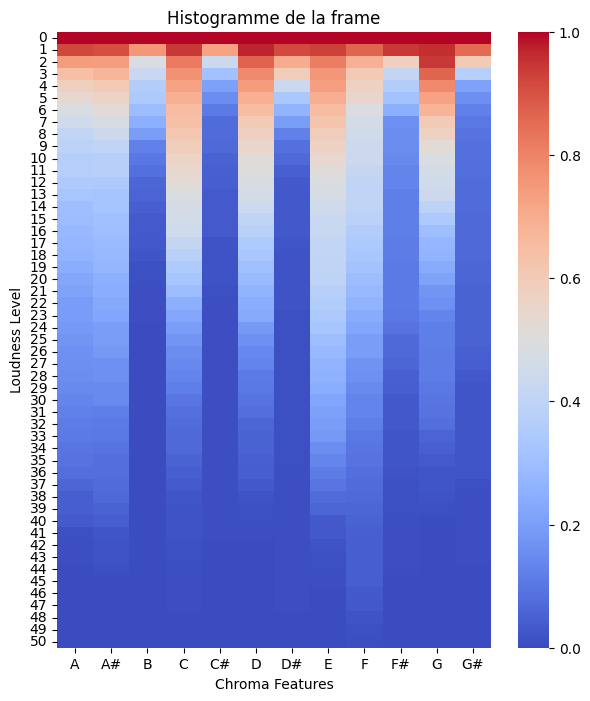

In [56]:
hist = dico['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3']
plot_histogram(hist[0])

In [58]:
with open ('hist_bach.pkl', 'wb') as f:
    pickle.dump(dico, f)

## Pre-processing des données

In [59]:
dico = pickle.load(open('hist_bach.pkl', 'rb'))

In [61]:
len(dico['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3'])

8

In [63]:
def transpose(hist,shift):
    """Transposition de l'histogramme de shift"""
    hist2 = np.roll(hist, shift, axis=1)
    return hist2

In [69]:
def distance_eucl(hist1, hist2):
    """Calcul la distance entre deux histogrammes.
    A modifier si on veut une autre distance !"""
    return np.sqrt(np.sum((hist1 - hist2)**2))

In [70]:
def distance(hist0,hist1):
    return min([distance_eucl(hist0, transpose(hist1, i)) for i in range(12)])

def distance_morceaux(frames0,frames1):
    return sum([distance(frames0[i],frames1[i]) for i in range(len(frames0))])

In [76]:
hist = dico['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3']
hist2 = dico['01_bach/CrossComp-0071_01_bach_trio_gdur_bwv_586.mp3']
distance(hist,hist2)

10.97907223218914

## Clustering sur les morceaux de Bach

In [6]:
def k_means_clustering(data, n_clusters=10):
    """
    Applies KMeans clustering to the data.
    """
    data_flattened = np.array([data[i][2].flatten() for i in range(len(data))])
    identifiers = np.array([(data[i][0],data[i][1]) for i in range(len(data))])
    kmeans = KMeans(n_clusters = n_clusters, random_state=42)
    clusters = kmeans.fit_predict(data_flattened)
    results = np.column_stack((identifiers, clusters))
    return data_flattened,results, kmeans.cluster_centers_

In [10]:
data_flattened,res, centroids = k_means_clustering(data, n_clusters=99)

In [7]:
res[:,2]

array(['55', '70', '70', ..., '80', '80', '80'], dtype='<U110')

In [7]:
def affichage(data_flattened, resultats):
    pca = PCA(n_components=2)
    data_reduced = pca.fit_transform(data_flattened)
    df = pd.DataFrame(data_reduced, columns=['PC1', 'PC2'])
    df['Cluster'] = resultats[:,2]
    df['Title'] = resultats[:,0]
    df['Start'] = resultats[:,1]
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=10, alpha=0.7)

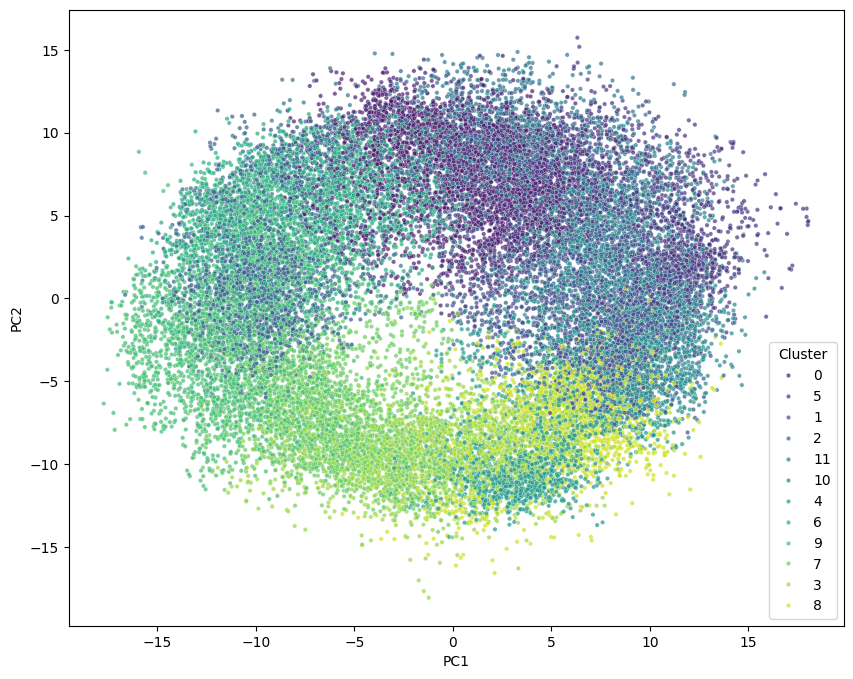

In [13]:
affichage(data_flattened,res)

In [8]:
def affichage_centroides(data_flattened, resultats, centroids):
    pca = PCA(n_components=2)
    data_reduced = pca.fit_transform(data_flattened)
    df = pd.DataFrame(data_reduced, columns=['PC1', 'PC2'])
    df['Cluster'] = resultats[:,2]
    df['Title'] = resultats[:,0]
    df['Start'] = resultats[:,1]
    plt.figure(figsize=(10, 8))
    centroids = pca.transform(centroids)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='Title', palette='viridis', s=10, alpha=0.5, legend = False)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

In [15]:
res[:,0]

array(['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3',
       '01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3',
       '01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3', ...,
       '01_bach/CrossComp-0071_01_bach_trio_gdur_bwv_586.mp3',
       '01_bach/CrossComp-0071_01_bach_trio_gdur_bwv_586.mp3',
       '01_bach/CrossComp-0071_01_bach_trio_gdur_bwv_586.mp3'],
      dtype='<U110')

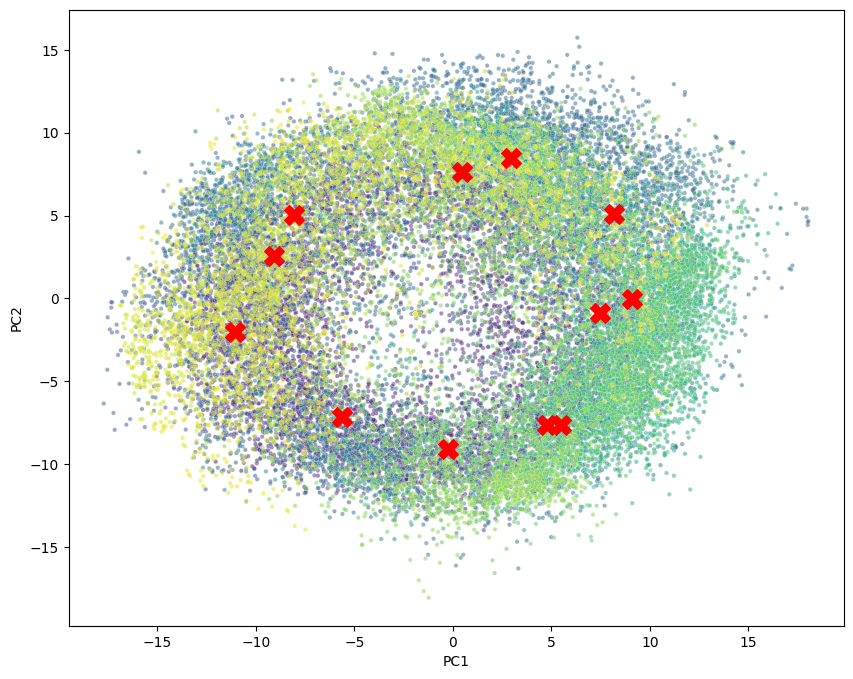

In [16]:
affichage_centroides(data_flattened,res, centroids)

### Visualisation avec plotly

In [9]:
def affichage_plotly_3D(data_flattened,resultats, centroids):
    pca = PCA(n_components=3)
    data_reduced = pca.fit_transform(data_flattened)
    df = pd.DataFrame(data_reduced, columns=['PC1', 'PC2','PC3'])
    df['Cluster'] = resultats[:,2]
    df['Title'] = resultats[:,0]
    print(f"Nombre de titres : {len(df['Title'].unique())}")
    df['Start'] = resultats[:,1]
    plt.figure(figsize=(10, 8))
    centroids = pca.transform(centroids)
    fig = px.scatter_3d(df, x='PC1', y='PC2', z= 'PC3', color='Cluster', symbol = "Title", hover_name = 'Title', hover_data=['Start'], title='3D Scatter Plot of Clusters')
    fig.update_layout(showlegend=False)
    fig.update_traces(marker=dict(size=1))
    #plot(fig, filename='scatter_3d.html', auto_open=True)
    pio.show(fig)

In [ ]:
affichage_plotly_3D(data_flattened,res, centroids)

Nombre de titres : 99


<Figure size 1000x800 with 0 Axes>

## Calcul de l'efficacité

In [10]:
data_flattened,res, centroids = k_means_clustering(data, n_clusters=10)

In [11]:
def new_data(data_flattened,resultats):
    pca = PCA(n_components=3)
    data_reduced = pca.fit_transform(data_flattened)
    df = pd.DataFrame(data_reduced, columns=['PC1', 'PC2','PC3'])
    df['Cluster'] = resultats[:,2]
    df['Title'] = resultats[:,0]
    df['Start'] = resultats[:,1]
    return df

In [12]:
def affiche_distrib_cluster(data_flattened,res,cluster):
    df = new_data(data_flattened,res)
    stats = df.groupby(['Cluster', 'Title']).size().reset_index(name='Count')
    clust = stats[stats['Cluster']==cluster].sort_values(by = 'Count',ascending = False)
    sns.histplot(data=clust, x='Title', weights='Count', bins=len(clust['Title'].unique()), kde=False)
    plt.xticks(rotation=90)

In [13]:
def affiche_distrib_titre(data_flattened,res):
    df = new_data(data_flattened,res)
    titres = df['Title'].unique()
    titre = np.random.choice(titres)
    stats = df.groupby(['Cluster', 'Title']).size().reset_index(name='Count')
    clust = stats[stats['Title']==titre].sort_values(by = 'Count',ascending = False)
    sns.histplot(data=clust, x='Cluster', weights='Count', bins=len(clust['Cluster'].unique()), kde=False)
    plt.title(str(titre))
    plt.xticks(rotation=90)

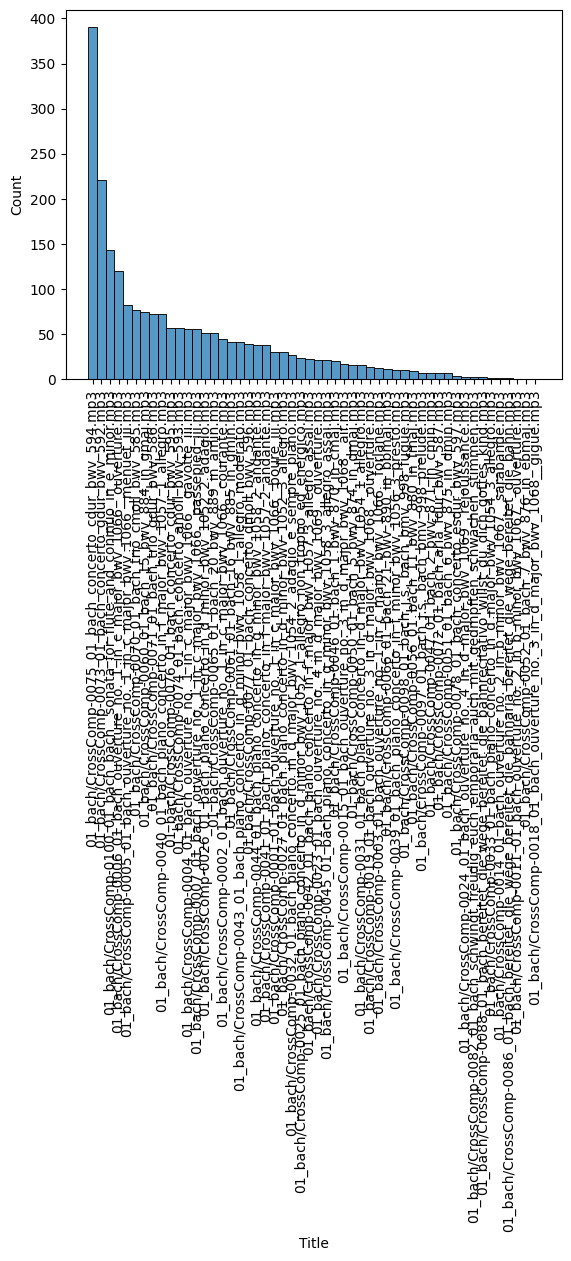

In [17]:
affiche_distrib_cluster(data_flattened,res,'1')

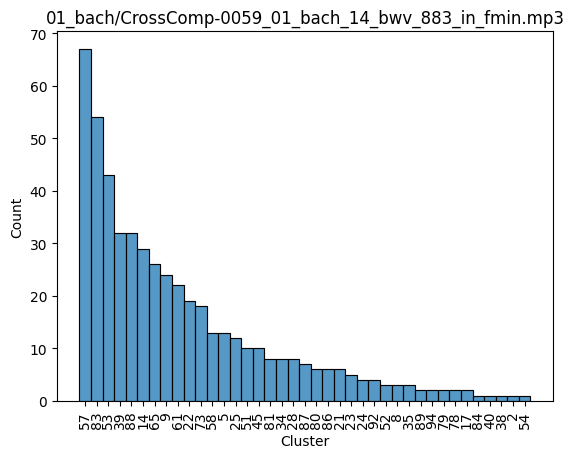

In [64]:
affiche_distrib_titre(data_flattened,res)